In [1]:
from measurments import Sim, map_unstructured_to_structured_3d_optimized
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({
    "text.usetex": False,
    "text.latex.preamble": r"""
        \usepackage{amsmath}
        \usepackage{bm}
        \usepackage{geometry}
    """,
    "font.family": "serif",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "axes.linewidth": 1.5,       # Thicker border
    "xtick.major.width": 1.2,    # Thicker x ticks
    "ytick.major.width": 1.2,    # Thicker y ticks
    "xtick.labelsize": 14,       # Larger tick labels
    "ytick.labelsize": 14,
    "axes.labelsize": 16,        # Larger axis labels
    "axes.titlesize": 18,        # Larger title
    "lines.linewidth": 2.0
})

In [3]:
sol = Sim("/u/jbiba/projects/turbulent-driving/iso-driving128-mach10")
mix = Sim("/u/jbiba/projects/turbulent-driving/iso-driving128-mach10-mix")

In [5]:
len(sol.snaps)

105

(<matplotlib.image.AxesImage at 0x14efd01a1590>,
 array([[2.44868147, 2.50406716, 2.50406716, ..., 2.53363276, 2.53363276,
         2.53363276],
        [2.44868147, 2.44868147, 2.57964044, ..., 2.53363276, 2.53363276,
         2.53363276],
        [2.44868147, 2.44868147, 2.44868147, ..., 2.53363276, 2.53363276,
         2.51994301],
        ...,
        [2.44346408, 2.44346408, 2.44346408, ..., 2.14590826, 2.14590826,
         2.14590826],
        [2.44346408, 2.44346408, 2.44346408, ..., 2.14590826, 2.14590826,
         2.14590826],
        [2.44346408, 2.44346408, 2.44346408, ..., 2.14590826, 2.14590826,
         2.14590826]], shape=(200, 200)))

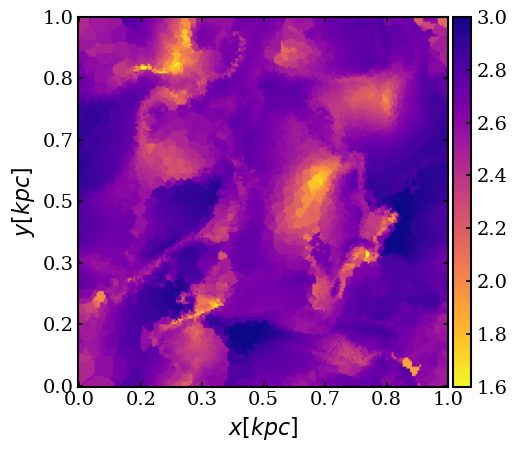

In [7]:
fig, ax = plt.subplots()
sol.prop_image(100, "Velocities", fig, ax, grid=200, norm="log", cmap="plasma_r", vmin=1.6, vmax=3.0)

100%|██████████| 98/98 [01:09<00:00,  1.42it/s]


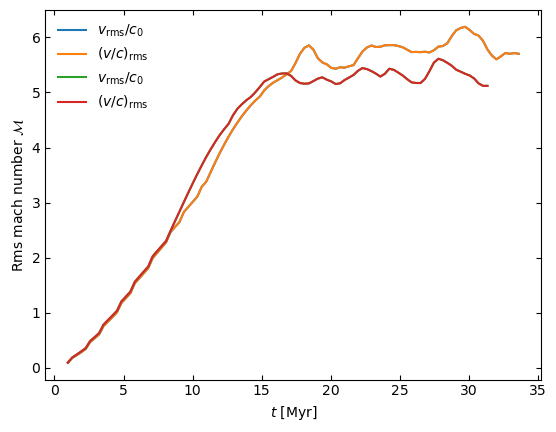

In [15]:
fig, ax = plt.subplots()
plots_sol, data_sol = sol.mach_number_plot(fig, ax)
plots_mix, data_mix = mix.mach_number_plot(fig, ax)

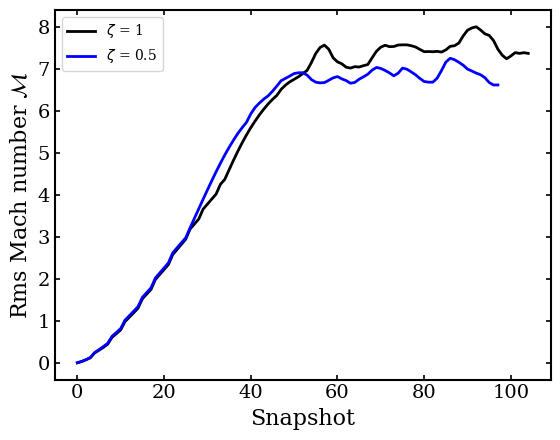

In [21]:
fig, ax = plt.subplots()
plots_sol = ax.plot(data_sol[:, 1]/75.6)
plots_mix = ax.plot(data_mix[:, 1]/75.6)

plots_sol[0].set_color("black")
plots_sol[0].set_label(r"$\zeta$ = 1")

plots_mix[0].set_color("blue")
plots_mix[0].set_label(r"$\zeta$ = 0.5")

ax.set_xlabel(r"Snapshot")
ax.set_ylabel(r"Rms Mach number $\mathcal{M}$")

ax.legend()
fig.savefig("isothermal-mach10-machnumber.pdf")

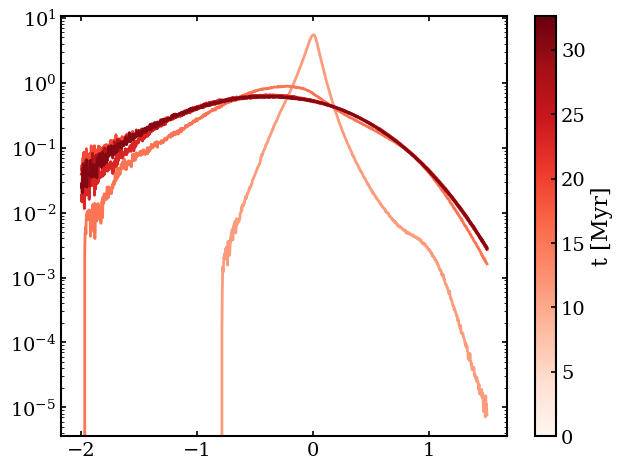

In [23]:
fig, ax = plt.subplots()
sol.property_pdf_evolution("Density", fig, ax, start=30, stop=102, num_evol=6, avg=10)

In [24]:
ax.set_ylim(1e-2)
ax.set_xlabel(r"$\log(\rho/\langle\rho\rangle)$")
ax.set_ylabel("Volume weighted PDF")
fig.tight_layout()
fig.savefig("isothermal_density_pdf_evolution_sol.pdf", bbox_inches='tight')

Text(0, 0.5, 'Volume weighted PDF')

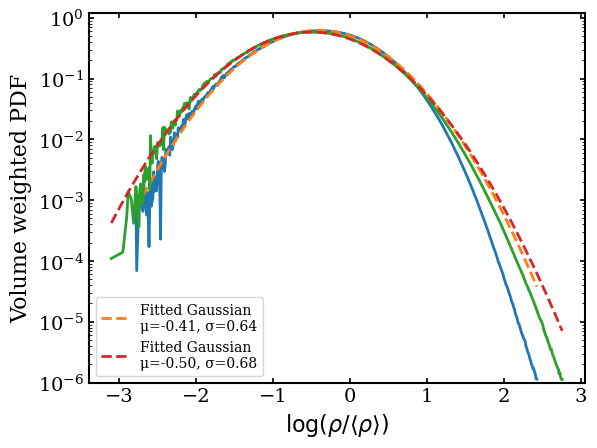

In [5]:
fig, ax = plt.subplots()
line_sol, gauss_sol = sol.property_pdf("Density", 60, fig, ax, avg=100, hist_range=(-5, 5))
line_mix, gauss_mix = mix.property_pdf("Density", 60, fig, ax, avg=100, hist_range=(-5, 5))
ax.set_xlabel(r"$\log(\rho/\langle\rho\rangle)$")
ax.set_ylabel("Volume weighted PDF")

In [7]:
gauss_sol[0].set_alpha(0.5)
gauss_mix[0].set_alpha(0.5)
gauss_sol[0].set_color("orange")
gauss_mix[0].set_color("green")
line_sol[0].set_color("orange")
line_mix[0].set_color("green")
line_sol[0].set_label(r"$\zeta = 1$")
line_mix[0].set_label(r"$\zeta = 0.5$")
ax.legend()
fig.savefig("isothermal_density_pdf_sol_mix_comparison_snap60-average.pdf", bbox_inches="tight")

In [5]:
dens = sol.load(100, "Density")
masses = sol.load(100, "Masses")

In [ ]:
volumes = masses/dens
mean_dens = np.sum(dens*volumes)

s = np.log(dens/mean_dens)

mean_s = np.sum(s*volumes)
print(mean_s)

variance = np.sum(s**2 * volumes) - mean_s**2
print(variance, np.sqrt(variance))

-1.0232196583354072
2.2248880379340803 1.491605858775729


In [10]:
3*np.sqrt(np.exp(variance) - 1)

np.float64(8.618121686635915)

In [ ]:
# 6.86
# 7.34

In [24]:
variances = list()

for i in range(len(sol.snaps)):
    dens = sol.load(i, "Density")
    masses = sol.load(i, "Masses")
    volumes = masses/dens
    mean_dens = np.sum(dens*volumes)

    s = np.log(dens/mean_dens)

    mean_s = np.sum(s*volumes)
    variance = np.sum(s**2 * volumes) - mean_s**2
    variances.append(variance)

variances = np.array(variances)

variances_mix = list()

for i in range(len(mix.snaps)):
    dens = mix.load(i, "Density")
    masses = mix.load(i, "Masses")
    volumes = masses/dens
    mean_dens = np.sum(dens*volumes)

    s = np.log(dens/mean_dens)

    mean_s = np.sum(s*volumes)
    variance = np.sum(s**2 * volumes) - mean_s**2
    variances_mix.append(variance)

variances_mix = np.array(variances_mix)

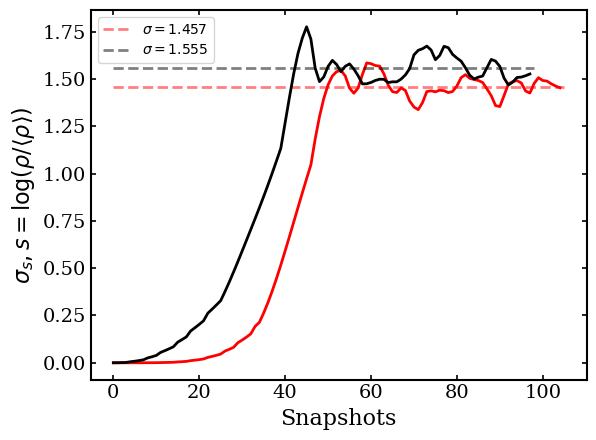

In [25]:
fig, ax = plt.subplots()
ax.plot(np.sqrt(variances), color="red")
mean_var = np.mean(np.sqrt(variances[60:]))
ax.hlines(mean_var, 0, len(variances), color="red", alpha=0.5, linestyle="--", label=f"$\\sigma = {mean_var:.3f}$")
ax.plot(np.sqrt(variances_mix), color="black")
mean_var_mix = np.mean(np.sqrt(variances_mix[60:]))
ax.hlines(mean_var_mix, 0, len(variances_mix), color="black", alpha=0.5, linestyle="--", label=f"$\\sigma = {mean_var_mix:.3f}$")
ax.legend()
ax.set_xlabel("Snapshots")
ax.set_ylabel(r"$\sigma_s, s = \mathrm{log}(\rho/\langle \rho\rangle)$")
fig.savefig("isothermal-density-variance.pdf")

In [26]:
b_sol = np.sqrt(np.exp(np.mean(variances[60:])) - 1)/7.34
b_mix = np.sqrt(np.exp(np.mean(variances_mix[60:])) - 1)/6.86

In [27]:
b_sol, b_mix

(np.float64(0.36996982947817736), np.float64(0.4673832309035506))

In [28]:
err_sol = np.std(variances[60:])
err_mix = np.std(variances_mix[60:])

b_err_sol = np.exp(np.mean(variances[60:]))*err_sol/(2*7.34**2 * b_sol)
b_err_mix = np.exp(np.mean(variances_mix[60:]))*err_mix/(2*6.86**2 * b_mix)

print(b_err_sol, b_err_mix)

0.03347143715177454 0.052502072506441545


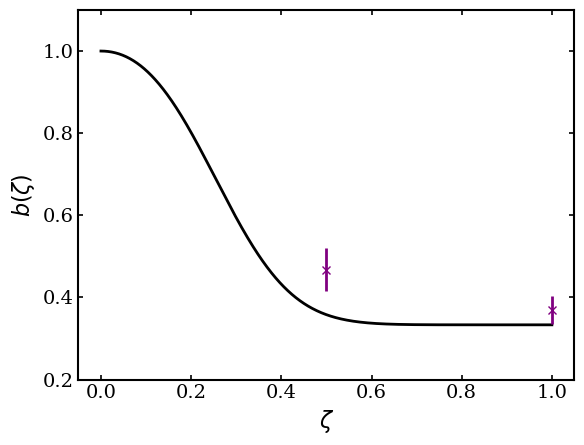

In [29]:
fig, ax = plt.subplots()
zeta = np.linspace(0, 1, 1000)

b = 1/3 + 2/3 * ((1 - zeta)**2/(1 - 2*zeta + 3*zeta**2))**3
ax.plot(zeta, b, color="black")
ax.errorbar([1, 0.5], [b_sol, b_mix], yerr=[b_err_sol, b_err_mix], fmt="x", color="purple")
ax.set_xlabel(r"$\zeta$")
ax.set_ylabel(r"$b(\zeta)$")
ax.set_ylim(0.2, 1.1)
fig.savefig("isothermal-dens-mach-dispersion.pdf")

In [22]:
v_rms = list()

for i in range(60, 95):
    vels = sol.load(i, "Velocities")
    dens = sol.load(i, "Density")
    masses = sol.load(i, "Masses")
    vols = masses/dens
    bulk_v = np.sum(vols[:, np.newaxis] * vels, axis=0)

    vels_corr = vels - bulk_v
    v_rms.append(np.sqrt(np.sum(np.sum(vels_corr**2, axis=-1)*vols))/75.6)

v_rms = np.array(v_rms)

In [23]:
np.mean(v_rms)

np.float64(7.344145294013377)

In [32]:
sim1 = Sim("/u/jbiba/projects/turbulent-driving/driving128-mach0.5")

v_rms = list()

for i in range(300, 400):
    vels = sim1.load(i, "Velocities")
    dens = sim1.load(i, "Density")
    masses = sim1.load(i, "Masses")
    vols = masses/dens
    bulk_v = np.sum(vols[:, np.newaxis] * vels, axis=0)

    vels_corr = vels - bulk_v
    v_rms.append([np.sqrt(np.sum(np.sum(vels_corr**2, axis=-1)*vols)), np.sqrt(np.sum(np.sum(vels**2, axis=-1)*vols))])

v_rms = np.array(v_rms)

In [33]:
np.mean(v_rms[:, 0]), np.mean(v_rms[:, 1])

(np.float64(36.50522787017433), np.float64(36.50641865327593))

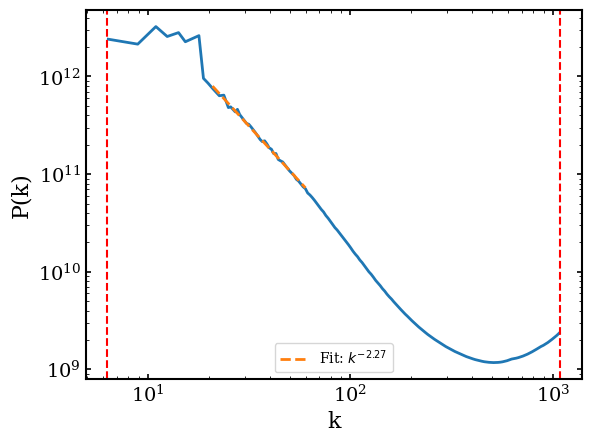

In [34]:
fig, ax = plt.subplots()
sol_line, sol_fit, sol_data = sol.velocity_power_spectrum(60, fig, ax, grid=200, avg=200)

In [35]:
sol_line[0].set_color("purple")
sol_fit[0].set_color("black")
sol_line[0].set_label(r"$\zeta = 1$")
sol_fit[0].set_alpha(1)
ax.legend()
fig.savefig("isothermal_vps_sol_averaged.pdf")

In [36]:
energy_in_list_sol = np.zeros(len(sol.snaps))
energy_in_list_mix = np.zeros(len(mix.snaps))


for i in range(len(sol.snaps)):
    data = sol.load(i, ["Density", "Acceleration", "Masses", "Velocities"])
    volume = data["Masses"]/data["Density"]
    force = data["Masses"][:, np.newaxis]*data["Acceleration"]
    f_dot_v = np.sum(force * data["Velocities"], axis=1)
    energy_in_list_sol[i] = np.sum(data["Density"] * f_dot_v * volume)

for i in range(len(mix.snaps)):
    data = mix.load(i, ["Density", "Acceleration", "Masses", "Velocities"])
    volume = data["Masses"]/data["Density"]
    force = data["Masses"][:, np.newaxis]*data["Acceleration"]
    f_dot_v = np.sum(force * data["Velocities"], axis=1)
    energy_in_list_mix[i] = np.sum(data["Density"] * f_dot_v * volume)

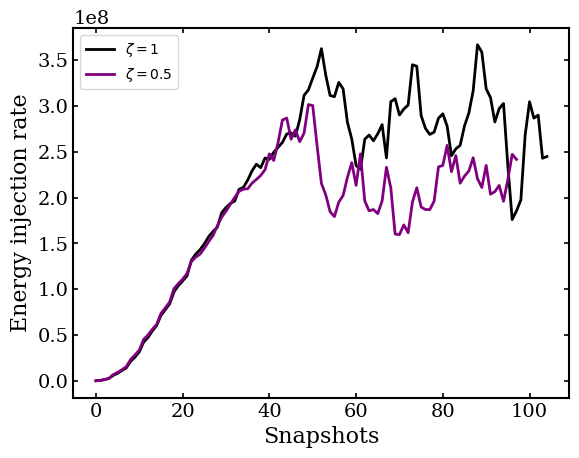

In [37]:
fig, ax = plt.subplots()
ax.plot(energy_in_list_sol, label=r"$\zeta = 1$", color="black")
ax.plot(energy_in_list_mix, label=r"$\zeta = 0.5$", color="purple")
ax.set_xlabel("Snapshots")
ax.set_ylabel("Energy injection rate")
ax.legend()
fig.savefig("isothermal-energy-inj-comparison.pdf")

In [38]:
force_in_list_sol = np.zeros(len(sol.snaps))
force_in_list_mix = np.zeros(len(mix.snaps))


for i in range(len(sol.snaps)):
    data = sol.load(i, ["Acceleration", "Masses", "Density"])
    vols = data["Masses"]/data["Density"]
    force = data["Masses"][:, np.newaxis]*data["Acceleration"]
    force_in_list_sol[i] = np.sqrt(np.sum(np.sum(force**2, axis=-1)*vols))

for i in range(len(mix.snaps)):
    data = mix.load(i, ["Acceleration", "Masses", "Density"])
    vols = data["Masses"]/data["Density"]
    force = data["Masses"][:, np.newaxis]*data["Acceleration"]
    force_in_list_mix[i] = np.sqrt(np.sum(np.sum(force**2, axis=-1)*vols))

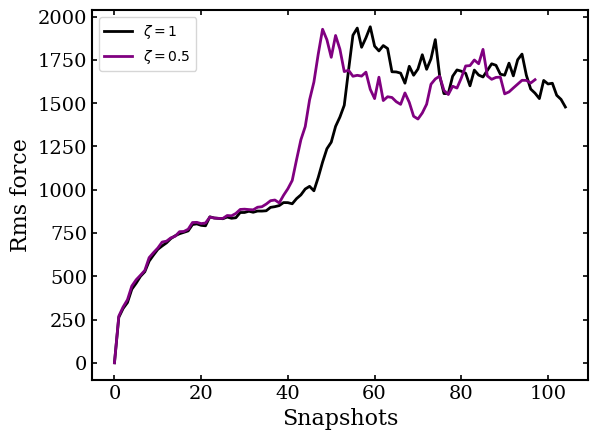

In [39]:
fig, ax = plt.subplots()
ax.plot(force_in_list_sol, label=r"$\zeta = 1$", color="black")
ax.plot(force_in_list_mix, label=r"$\zeta = 0.5$", color="purple")
ax.set_xlabel("Snapshots")
ax.set_ylabel("Rms force")
ax.legend()
fig.savefig("isothermal-rmsforce-comparison.pdf")

In [53]:
sim1 = Sim("/u/jbiba/projects/turbulent-driving/driving128-mach0.5-comp")

ratios = list()

for i in range(300, len(sim1.snaps)):
    vels = sim1.load(i, "Acceleration")
    pos = sim1.load(i, "Coordinates")

    n = 200

    vels_grid = map_unstructured_to_structured_3d_optimized(pos, vels, (n, n, n))

    field_k = np.fft.fftn(vels_grid, axes=(0, 1, 2))
        
    # Generate wavevectors
    kx = np.fft.fftfreq(n) * n
    ky = np.fft.fftfreq(n) * n
    kz = np.fft.fftfreq(n) * n
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    K = np.stack((KX, KY, KZ), axis=-1)  # shape: (n, n, n, 3)

    # Compute |k|^2 and avoid division by zero
    k_squared = np.sum(K**2, axis=-1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        k_unit = np.divide(K, k_squared, where=(k_squared != 0))

    # Compute k · V_k (scalar projection)
    k_dot_v = np.sum(field_k * np.conj(K), axis=-1, keepdims=True)

    # Compressive component in Fourier space: (k · v) * k / |k|^2
    v_comp_k = k_dot_v * k_unit
    v_comp_k[np.isnan(v_comp_k)] = 0  # Handle NaNs due to division by zero

    # Compute RMS in Fourier space
    total_rms = np.sqrt(np.mean(np.abs(field_k)**2))
    comp_rms = np.sqrt(np.mean(np.abs(v_comp_k)**2))

    ratios.append(comp_rms / total_rms)

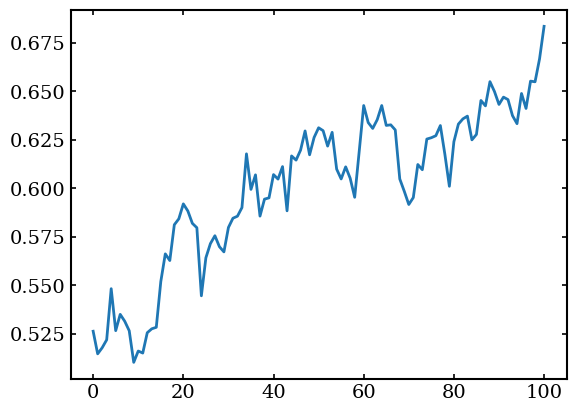

In [55]:
plt.plot(ratios)

In [56]:
sim1 = Sim("/u/jbiba/projects/turbulent-driving/driving128-mach0.5")

ratios = list()

for i in range(300, len(sim1.snaps)):
    vels = sim1.load(i, "Acceleration")
    pos = sim1.load(i, "Coordinates")

    n = 200

    vels_grid = map_unstructured_to_structured_3d_optimized(pos, vels, (n, n, n))

    field_k = np.fft.fftn(vels_grid, axes=(0, 1, 2))
        
    # Generate wavevectors
    kx = np.fft.fftfreq(n) * n
    ky = np.fft.fftfreq(n) * n
    kz = np.fft.fftfreq(n) * n
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    K = np.stack((KX, KY, KZ), axis=-1)  # shape: (n, n, n, 3)

    # Compute |k|^2 and avoid division by zero
    k_squared = np.sum(K**2, axis=-1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        k_unit = np.divide(K, k_squared, where=(k_squared != 0))

    # Compute k · V_k (scalar projection)
    k_dot_v = np.sum(field_k * np.conj(K), axis=-1, keepdims=True)

    # Compressive component in Fourier space: (k · v) * k / |k|^2
    v_comp_k = k_dot_v * k_unit
    v_comp_k[np.isnan(v_comp_k)] = 0  # Handle NaNs due to division by zero

    # Compute RMS in Fourier space
    total_rms = np.sqrt(np.mean(np.abs(field_k)**2))
    comp_rms = np.sqrt(np.mean(np.abs(v_comp_k)**2))

    ratios.append(comp_rms / total_rms)

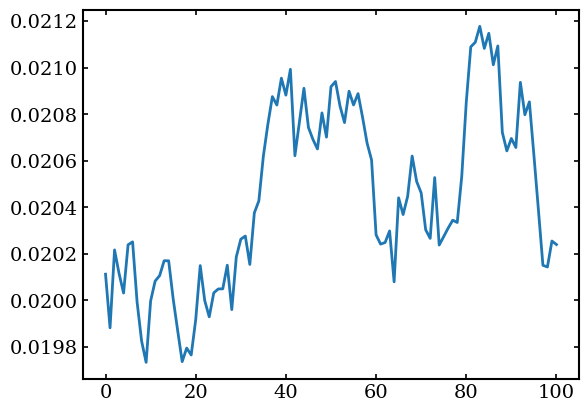

In [57]:
plt.plot(ratios)

In [74]:
sim1 = Sim("/u/jbiba/projects/turbulent-driving/driving128-mach0.5-comp")

snap = 200
vels = sim1.load(snap, "Acceleration")
pos = sim1.load(snap, "Coordinates")

n = 128

vels_grid = map_unstructured_to_structured_3d_optimized(pos, vels, (n, n, n))

field_k = np.fft.fftn(vels_grid, axes=(0, 1, 2))
    
# Generate wavevectors
kx = np.fft.fftfreq(n) * n
ky = np.fft.fftfreq(n) * n
kz = np.fft.fftfreq(n) * n
KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
K = np.stack((KX, KY, KZ), axis=-1)  # shape: (n, n, n, 3)

# Compute |k|^2 and avoid division by zero
k_squared = np.sum(K**2, axis=-1, keepdims=True)
with np.errstate(divide='ignore', invalid='ignore'):
    k_unit = np.divide(K, k_squared, where=(k_squared != 0))

# Compute k · V_k (scalar projection)
k_dot_v = np.sum(field_k * np.conj(K), axis=-1, keepdims=True)

# Compressive component in Fourier space: (k · v) * k / |k|^2
v_comp_k = k_dot_v * k_unit
v_comp_k[np.isnan(v_comp_k)] = 0  # Handle NaNs due to division by zero

# Compute RMS in Fourier space
total_rms = np.sqrt(np.mean(np.abs(field_k)**2))
comp_rms = np.sqrt(np.mean(np.abs(v_comp_k)**2))

print(comp_rms / total_rms)

0.53427165017878


In [38]:
sol_driving = list()
mix_driving = list()

# 6.86
# 7.34


for i in range(60, len(sol.snaps)):
    data = sol.load(i, ["Masses", "Density", "Velocities", "Coordinates"])
    vols = data["Masses"]/data["Density"]
    mean_dens = np.sum(vols*data["Density"])
    std_dens = np.sqrt(np.sum(vols*data["Density"]**2) - mean_dens**2)
    bulk_v = np.sum(vols[:, np.newaxis] * data["Velocities"], axis=0)

    vels_corr = vels - bulk_v
    m_rms = np.sqrt(np.sum(np.sum(vels_corr**2, axis=-1)*vols))/75.6
    sol_driving.append(std_dens/(mean_dens*m_rms))



for i in range(60, len(mix.snaps)):
    data = mix.load(i, ["Masses", "Density", "Velocities", "Coordinates"])
    vols = data["Masses"]/data["Density"]
    mean_dens = np.sum(vols*data["Density"])
    std_dens = np.sqrt(np.sum(vols*data["Density"]**2) - mean_dens**2)
    bulk_v = np.sum(vols[:, np.newaxis] * data["Velocities"], axis=0)

    vels_corr = vels - bulk_v
    m_rms = np.sqrt(np.sum(np.sum(vels_corr**2, axis=-1)*vols))/75.6
    mix_driving.append(std_dens/(mean_dens*m_rms))

In [39]:
np.mean(mix_driving), np.std(mix_driving)

(np.float64(0.40740573574042505), np.float64(0.04553772236901333))

In [ ]:
sol_ratios = list()
mix_ratios = list()

for i in range(60, len(sol.snaps)):
    vels = sol.load(i, "Velocities")
    pos = sol.load(i, "Coordinates")

    n = 128

    vels_grid = map_unstructured_to_structured_3d_optimized(pos, vels, (n, n, n))

    field_k = np.fft.fftn(vels_grid, axes=(0, 1, 2))
        
    # Generate wavevectors
    kx = np.fft.fftfreq(n) * n
    ky = np.fft.fftfreq(n) * n
    kz = np.fft.fftfreq(n) * n
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    K = np.stack((KX, KY, KZ), axis=-1)  # shape: (n, n, n, 3)

    # Compute |k|^2 and avoid division by zero
    k_squared = np.sum(K**2, axis=-1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        k_unit = np.divide(K, k_squared, where=(k_squared != 0))

    # Compute k · V_k (scalar projection)
    k_dot_v = np.sum(field_k * np.conj(K), axis=-1, keepdims=True)

    # Compressive component in Fourier space: (k · v) * k / |k|^2
    v_comp_k = k_dot_v * k_unit
    v_comp_k[np.isnan(v_comp_k)] = 0  # Handle NaNs due to division by zero

    # Compute RMS in Fourier space
    total_power_long = np.sum(np.abs(v_comp_k)**2)
    total_power = np.sum(np.abs(field_k)**2)

    sol_ratios.append(total_power_long / total_power)


for i in range(60, len(mix.snaps)):
    vels = mix.load(i, "Velocities")
    pos = mix.load(i, "Coordinates")

    n = 128

    vels_grid = map_unstructured_to_structured_3d_optimized(pos, vels, (n, n, n))

    field_k = np.fft.fftn(vels_grid, axes=(0, 1, 2))
        
    # Generate wavevectors
    kx = np.fft.fftfreq(n) * n
    ky = np.fft.fftfreq(n) * n
    kz = np.fft.fftfreq(n) * n
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing='ij')
    K = np.stack((KX, KY, KZ), axis=-1)  # shape: (n, n, n, 3)

    # Compute |k|^2 and avoid division by zero
    k_squared = np.sum(K**2, axis=-1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        k_unit = np.divide(K, k_squared, where=(k_squared != 0))

    # Compute k · V_k (scalar projection)
    k_dot_v = np.sum(field_k * np.conj(K), axis=-1, keepdims=True)

    # Compressive component in Fourier space: (k · v) * k / |k|^2
    v_comp_k = k_dot_v * k_unit
    v_comp_k[np.isnan(v_comp_k)] = 0  # Handle NaNs due to division by zero

    # Compute RMS in Fourier space
    total_power_long = np.sum(np.abs(v_comp_k)**2)
    total_power = np.sum(np.abs(field_k)**2)

    mix_ratios.append(total_power_long / total_power)

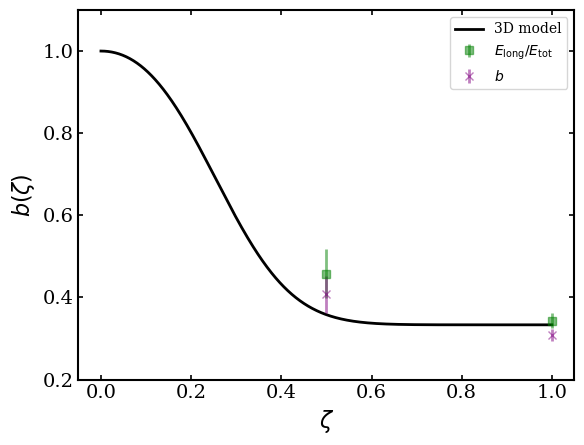

In [43]:
fig, ax = plt.subplots()
zeta = np.linspace(0, 1, 1000)

b = 1/3 + 2/3 * ((1 - zeta)**2/(1 - 2*zeta + 3*zeta**2))**3
ax.plot(zeta, b, color="black", label="3D model")
ax.errorbar([1, 0.5], [np.mean(sol_ratios)*np.sqrt(3), np.mean(mix_ratios)*np.sqrt(3)], yerr=[np.std(sol_ratios)*np.sqrt(3), np.std(mix_ratios)*np.sqrt(3)], fmt="s", color="green", alpha=0.5, label=r"$E_\mathrm{long}/E_\mathrm{tot}$")
ax.errorbar([1, 0.5], [np.mean(sol_driving), np.mean(mix_driving)], yerr=[np.std(sol_driving), np.std(mix_driving)], fmt="x", color="purple", alpha=0.5,  label=r"$b$")
ax.set_xlabel(r"$\zeta$")
ax.set_ylabel(r"$b(\zeta)$")
ax.set_ylim(0.2, 1.1)
ax.legend()
fig.savefig("isothermal-compressive-ratio.pdf")

In [32]:
sol_driving

[np.float64(0.3052532718836485),
 np.float64(0.30400530170175133),
 np.float64(0.2900455431454456),
 np.float64(0.2720250915383791),
 np.float64(0.26419695896749695),
 np.float64(0.26697551837815203),
 np.float64(0.2800244122787982),
 np.float64(0.28928207588401306),
 np.float64(0.27909589538308494),
 np.float64(0.26562533379429487),
 np.float64(0.26066816166444834),
 np.float64(0.27404945250306706),
 np.float64(0.28588055871575063),
 np.float64(0.2899798109573638),
 np.float64(0.2867219800691526),
 np.float64(0.2840894005511855),
 np.float64(0.2842472180427973),
 np.float64(0.2812644325524212),
 np.float64(0.2707299858843348),
 np.float64(0.28251820117632437),
 np.float64(0.30160685286864847),
 np.float64(0.2956518654101477),
 np.float64(0.2945460796800534),
 np.float64(0.28708574021758304),
 np.float64(0.2700611752075257),
 np.float64(0.2595857145069991),
 np.float64(0.2547708485932364),
 np.float64(0.2839507314124907),
 np.float64(0.29209423811722085),
 np.float64(0.2732280075956342

In [34]:
v_comp_k[-1, -1, -1]

array([8827073.47285737-33389811.1167759j,
       8827073.47285737-33389811.1167759j,
       8827073.47285737-33389811.1167759j])